# Pastela Pharmaceuticals — Pharmacovigilance Risk Analytics
**Data Analyst Portfolio Project — Python, SQL & Tableau**

You are the newest data analyst on Pastela Pharmaceuticals' Data & Analytics team. The internal Pharmacovigilance department wants to move from reacting to adverse-event reports to proactively flagging high-risk active treatments. Your manager, Julian Cross, and your colleague, Priya Anand, have asked you to build the analysis end to end: pull the data with SQL, clean and model it in Python, and export the results for a Tableau dashboard.

Full background, the team roster, the kickoff emails, and the stakeholder interview are in [`docs/pharma_analytics_project_brief.md`](docs/pharma_analytics_project_brief.md).

**This is the exemplar** — a fully worked solution. Try the companion notebook, `data_analysis_portfolio_pharma.ipynb`, yourself first, then compare your approach to this one.

This notebook assumes its working directory is the project root (the folder containing `raw/`, `docs/`, and `processed/`).

## PACE stages

This project follows the **PACE** framework used throughout this portfolio:

* **Plan** — define the objective and success criteria
* **Analyze** — extract, clean, explore, and statistically test the data
* **Construct** — build and evaluate the predictive model
* **Execute** — export results, design the Tableau dashboard, and communicate findings

## PACE: Plan

### Task 1a. Define the objective

Read the stakeholder interview in the project brief, then answer:

1. What is the target variable this model predicts?

**Exemplar response:** A binary flag, `adverse_event_flag`, indicating whether a given treatment resulted in a reported adverse event. The model should output a *probability* (risk score), not just the flag, so Pharmacovigilance can rank and prioritize treatments.

2. Who is the end user of this model's output, and what decision will it inform?

**Exemplar response:** Helena Brooks's Pharmacovigilance monitoring team. They will use the risk score to decide which active treatments to proactively review or check in on, rather than waiting for a report to arrive.

3. What must the model explicitly *not* be used for (per Marcus's regulatory note)?

**Exemplar response:** It must not be framed as a clinical diagnosis or a prescribing recommendation. It is strictly a prioritization tool for the monitoring team, and the dashboard needs a plain-language explanation of what the risk score does and doesn't mean.

4. What accessibility constraint does the Tableau dashboard have to satisfy, and why?

**Exemplar response:** Helena has a visual impairment, so risk levels cannot be communicated through color alone — the dashboard needs text labels/icons in addition to color, and sufficient contrast.

5. Beyond individual treatments, what does the monitoring team need to watch at **site** level?

**Exemplar response:** Whether each hospital's data can be trusted. A site that reports late, under-reports events, or enrolls an unusual patient mix can distort every downstream number. Following risk-based quality management (RBQM, ICH E6(R3) / E8(R1)), we will define site-level Key Risk Indicators (KRIs) with **pre-specified limits** — a secondary (early-warning) limit and an action limit — and summarise them in a Site Risk Score.

### Task 1b. Imports and setup

Import the libraries needed across the whole pipeline: `pandas`/`numpy` for data handling, `sqlalchemy` for the SQL step, `matplotlib`/`seaborn` for visualization, `scipy`/`statsmodels` for statistical inference, and `scikit-learn` for modeling.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, brier_score_loss, RocCurveDisplay,
)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## PACE: Analyze

Consider these questions in your PACE Strategy Document while working through this stage:
* What do you do about missing data?
* Are there outliers, and how should you treat them?
* What do the distributions tell you about the problem you're solving?

### Task 2. Extract data with SQL

Pastela stores its pharmacovigilance data in the five source tables documented in [`raw/schema_pharma_analytics_db.sql`](raw/schema_pharma_analytics_db.sql). Rather than pulling every column of every table into memory, connect with Python (`SQLAlchemy`) and write a single filtering `JOIN` query that returns only the columns relevant to the adverse-event risk question — this keeps the heavy lifting in the database engine instead of pandas.

Here, the CSV files in `raw/` are first loaded into a local SQLite database (standing in for the company's data warehouse), so the SQL step below is a real SQL round-trip, not just `read_csv`.

Prescriber and site (`doctors`) are joined as well: they are not model inputs, but the Pharmacovigilance team needs them to filter the dashboard and to monitor sites. Patient and prescriber **names are deliberately not selected** (data minimisation): no downstream step needs them.

In [2]:
RAW_DIR = Path("raw")
PROCESSED_DIR = Path("processed")
PROCESSED_DIR.mkdir(exist_ok=True)
DB_PATH = PROCESSED_DIR / "pharma_analytics.db"

engine = create_engine(f"sqlite:///{DB_PATH}")

table_files = {
    "doctors": "doctors.csv",
    "medications": "medications.csv",
    "patients": "patients.csv",
    "treatments": "treatments.csv",
    "adverse_events": "adverse_events.csv",
}

for table_name, filename in table_files.items():
    raw_df = pd.read_csv(RAW_DIR / filename)
    raw_df.to_sql(table_name, engine, if_exists="replace", index=False)

print("Loaded tables into SQLite:", list(table_files))

Loaded tables into SQLite: ['doctors', 'medications', 'patients', 'treatments', 'adverse_events']


In [3]:
extraction_query = text("""
    SELECT
        p.patient_id,
        p.birth_date,
        p.sex,
        p.weight_kg,
        p.height_cm,
        t.treatment_id,
        t.start_date,
        t.end_date,
        t.dose_mg,
        t.frequency,
        t.route,
        t.status,
        t.indication,
        d.doctor_id,
        d.specialty AS doctor_specialty,
        d.hospital,
        m.medication_id,
        m.brand_name,
        m.active_ingredient,
        m.manufacturer,
        m.who_atc_category,
        m.requires_prescription,
        CASE WHEN ae.event_id IS NOT NULL THEN 1 ELSE 0 END AS adverse_event_flag,
        ae.event_date,
        ae.report_date,
        ae.severity,
        ae.reaction_type,
        ae.required_hospitalization
    FROM treatments t
    JOIN patients p ON p.patient_id = t.patient_id
    JOIN doctors d ON d.doctor_id = t.doctor_id
    JOIN medications m ON m.medication_id = t.medication_id
    LEFT JOIN adverse_events ae ON ae.treatment_id = t.treatment_id
""")

with engine.connect() as conn:
    df = pd.read_sql(extraction_query, conn)

df.shape

(31583, 28)

### Task 3. Data exploration and cleaning

Check dtypes, null counts, and duplicates. Decide what each null actually means before you touch it — a null `severity` here doesn't mean *missing data*, it means *no adverse event occurred*.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31583 entries, 0 to 31582
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                31583 non-null  int64  
 1   birth_date                31583 non-null  object 
 2   sex                       31583 non-null  object 
 3   weight_kg                 31583 non-null  float64
 4   height_cm                 31583 non-null  int64  
 5   treatment_id              31583 non-null  int64  
 6   start_date                31583 non-null  object 
 7   end_date                  24684 non-null  object 
 8   dose_mg                   31583 non-null  float64
 9   frequency                 31583 non-null  object 
 10  route                     31583 non-null  object 
 11  status                    31583 non-null  object 
 12  indication                31583 non-null  object 
 13  doctor_id                 31583 non-null  int64  
 14  doctor

In [5]:
df.isna().sum()

patient_id                      0
birth_date                      0
sex                             0
weight_kg                       0
height_cm                       0
treatment_id                    0
start_date                      0
end_date                     6899
dose_mg                         0
frequency                       0
route                           0
status                          0
indication                      0
doctor_id                       0
doctor_specialty                0
hospital                        0
medication_id                   0
brand_name                      0
active_ingredient               0
manufacturer                    0
who_atc_category                0
requires_prescription           0
adverse_event_flag              0
event_date                  29202
report_date                 29202
severity                    29202
reaction_type               29202
required_hospitalization    29202
dtype: int64

In [6]:
# severity / reaction_type / required_hospitalization are only null when there
# was no adverse event -- that's informative, not missing data
df["severity"] = df["severity"].fillna("None")
df["reaction_type"] = df["reaction_type"].fillna("None")
df["required_hospitalization"] = df["required_hospitalization"].fillna(0).astype(int)

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Dropped {duplicate_count} exact duplicate rows. New shape: {df.shape}")

Dropped 0 exact duplicate rows. New shape: (31583, 28)


### Task 3b. Record-level plausibility vs. site-level process deviations

Cleaning should remove values that are **impossible**, not values that are merely **unusual**. Each record is checked against hard plausibility rules: a report cannot precede its event, an event cannot precede the treatment, BMI and age must be physiologically possible, doses must be positive. Anything that breaks a rule is a recording error and is removed.

In [7]:
for col in ["birth_date", "start_date", "end_date", "event_date", "report_date"]:
    df[col] = pd.to_datetime(df[col])

df["report_lag_days"] = (df["report_date"] - df["event_date"]).dt.days

age = (df["start_date"] - df["birth_date"]).dt.days / 365.25
bmi = df["weight_kg"] / (df["height_cm"] / 100) ** 2

plausibility_rules = {
    "report before event": df["report_lag_days"] < 0,
    "report lag > 365 days": df["report_lag_days"] > 365,
    "event before treatment start": df["event_date"] < df["start_date"],
    "treatment ends before it starts": df["end_date"] < df["start_date"],
    "BMI outside 12-60": ~bmi.between(12, 60),
    "age outside 0-110": ~age.between(0, 110),
    "dose <= 0 mg": df["dose_mg"] <= 0,
}
violations = pd.Series({rule: int(mask.sum()) for rule, mask in plausibility_rules.items()})
print(violations.to_string())

impossible = np.logical_or.reduce(list(plausibility_rules.values()))
df = df[~impossible]
print(f"\nRemoved {impossible.sum()} impossible records. Shape: {df.shape}")

report before event                0
report lag > 365 days              0
event before treatment start       0
treatment ends before it starts    0
BMI outside 12-60                  0
age outside 0-110                  0
dose <= 0 mg                       0

Removed 0 impossible records. Shape: (31583, 29)


Every record passes. But the reporting lag looks very different from site to site. A naive outlier rule (the global IQR fence) would flag a large share of reports — let's see where they come from before deciding anything.

Global IQR upper fence: 8.5 days
Reports a naive IQR rule would drop: 197 of 2381
hospital
Northgate University Hospital    99
Summit Health System             98


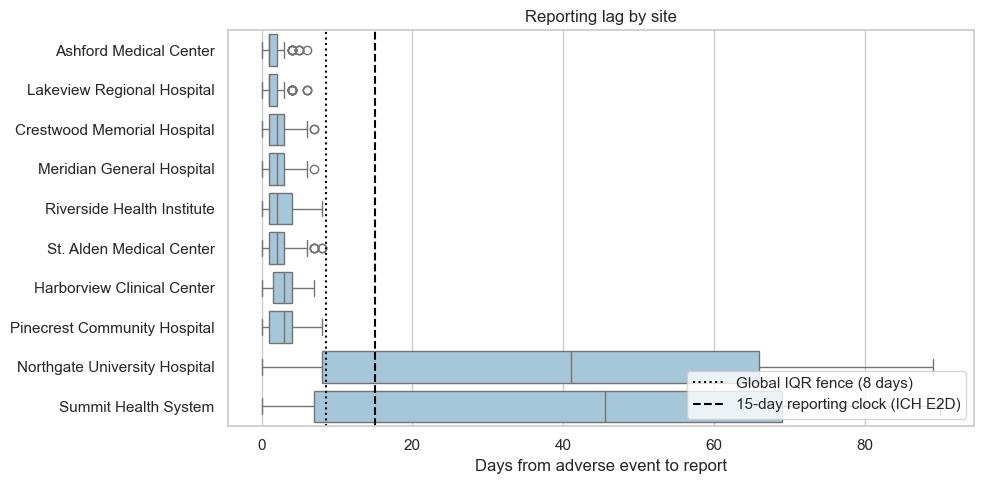

In [8]:
lags = df.dropna(subset=["report_lag_days"])
q1, q3 = lags["report_lag_days"].quantile([0.25, 0.75])
iqr_fence = q3 + 1.5 * (q3 - q1)
flagged = lags[lags["report_lag_days"] > iqr_fence]

print(f"Global IQR upper fence: {iqr_fence:.1f} days")
print(f"Reports a naive IQR rule would drop: {len(flagged)} of {len(lags)}")
print(flagged["hospital"].value_counts().head(5).to_string())

order = lags.groupby("hospital")["report_lag_days"].median().sort_values().index
plt.figure(figsize=(10, 5))
sns.boxplot(data=lags, y="hospital", x="report_lag_days", order=order, color="#9ecae1")
plt.axvline(iqr_fence, color="black", linestyle=":", label=f"Global IQR fence ({iqr_fence:.0f} days)")
plt.axvline(15, color="black", linestyle="--", label="15-day reporting clock (ICH E2D)")
plt.xlabel("Days from adverse event to report")
plt.ylabel("")
plt.title("Reporting lag by site")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Why these values are kept — they are neither outliers nor missing data to impute:**

* **Not outliers.** A 20–90 day reporting lag is a valid value inside the plausible range, and it is shared by most reports from the *same two sites*. An outlier is an isolated point; this is a **process pattern**. Dropping it with the IQR rule would delete hundreds of valid records from two entire sites — and with them, exactly the signal risk-based monitoring is looking for.
* **Not missing data to impute.** Events a slow site has not yet entered do not appear as `NaN`: they are **absent rows**, invisible to any record-level check. They can only be detected by aggregating — comparing observed vs. expected events per site (Task 11). Imputing them would mean inventing adverse events. At site level this is *missing not at random*, and the correct response is monitoring, not imputation.
* **Not an error.** The same logic applies to a site's patient mix: a hospital where most patients are women is clinically possible (specialty mix, referral population). Each record is valid; only the *site* profile is unusual.

> **Principle:** data cleaning fixes errors in **records**; risk-based monitoring watches deviations in **processes**. Confusing the two destroys the evidence.

### Task 4. Feature engineering

Combine and transform the raw columns into variables a model can actually use: patient age at the time treatment started, BMI, how many treatments a patient is on (polypharmacy), treatment duration, and the **dose relative to the medication's usual dose**.

Raw `dose_mg` is not comparable across 40 medications (0.05 mg of one drug and 500 mg of another can both be standard), so `dose_ratio` divides each dose by the median dose prescribed for that medication — an observable proxy for its typical dose.

*Limitation:* `polypharmacy_count` counts every treatment the patient has in the dataset, not only the ones overlapping in time. A production version should count concurrent treatments at the start date.

In [9]:
TODAY = pd.Timestamp("2026-08-17")  # data snapshot date

df["age_at_start"] = (df["start_date"] - df["birth_date"]).dt.days / 365.25
df["bmi"] = df["weight_kg"] / (df["height_cm"] / 100) ** 2
df["dose_ratio"] = df["dose_mg"] / df.groupby("medication_id")["dose_mg"].transform("median")

df["polypharmacy_count"] = df.groupby("patient_id")["treatment_id"].transform("count")

duration = (df["end_date"] - df["start_date"]).dt.days
ongoing_duration = (TODAY - df["start_date"]).dt.days
df["treatment_duration_days"] = duration.fillna(ongoing_duration)

df[["age_at_start", "bmi", "dose_ratio", "polypharmacy_count", "treatment_duration_days"]].describe()

,age_at_start,bmi,dose_ratio,polypharmacy_count,treatment_duration_days
count,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000
mean,50.757024,26.440766,1.000618,2.265744,151.584017
std,17.484451,5.227846,0.245422,0.944683,301.190312
min,11.802875,12.209640,0.480000,1.000000,7.000000
25%,38.457221,22.824490,0.830324,2.000000,14.000000
50%,50.554415,26.291724,1.000000,2.000000,51.000000
75%,62.377823,29.854302,1.168749,3.000000,121.000000
max,94.945927,49.110719,2.013693,4.000000,2384.000000


### Task 5. Descriptive statistics and exploratory visualization

Get a feel for the distributions before modeling anything, and look for an early visual signal that adverse events aren't randomly distributed across the population.

In [10]:
df[["age_at_start", "bmi", "dose_mg", "dose_ratio", "polypharmacy_count", "treatment_duration_days"]].describe()

,age_at_start,bmi,dose_mg,dose_ratio,polypharmacy_count,treatment_duration_days
count,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000
mean,50.757024,26.440766,143.581304,1.000618,2.265744,151.584017
std,17.484451,5.227846,264.782755,0.245422,0.944683,301.190312
min,11.802875,12.209640,0.050000,0.480000,1.000000,7.000000
25%,38.457221,22.824490,6.530000,0.830324,2.000000,14.000000
50%,50.554415,26.291724,24.440000,1.000000,2.000000,51.000000
75%,62.377823,29.854302,78.110000,1.168749,3.000000,121.000000
max,94.945927,49.110719,1855.320000,2.013693,4.000000,2384.000000


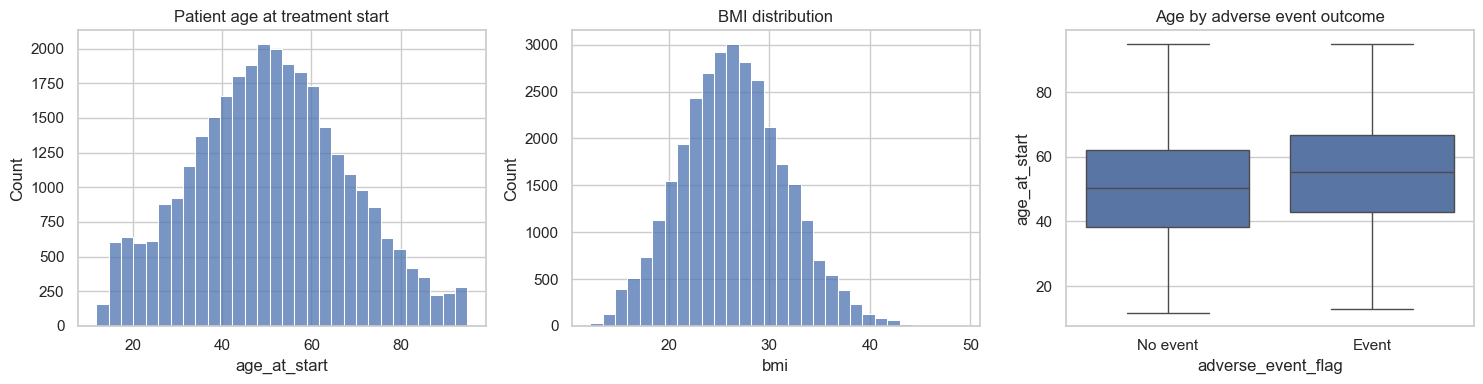

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["age_at_start"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Patient age at treatment start")

sns.histplot(df["bmi"], bins=30, ax=axes[1], color="#4C72B0")
axes[1].set_title("BMI distribution")

sns.boxplot(data=df, x="adverse_event_flag", y="age_at_start", ax=axes[2])
axes[2].set_title("Age by adverse event outcome")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["No event", "Event"])

plt.tight_layout()
plt.show()

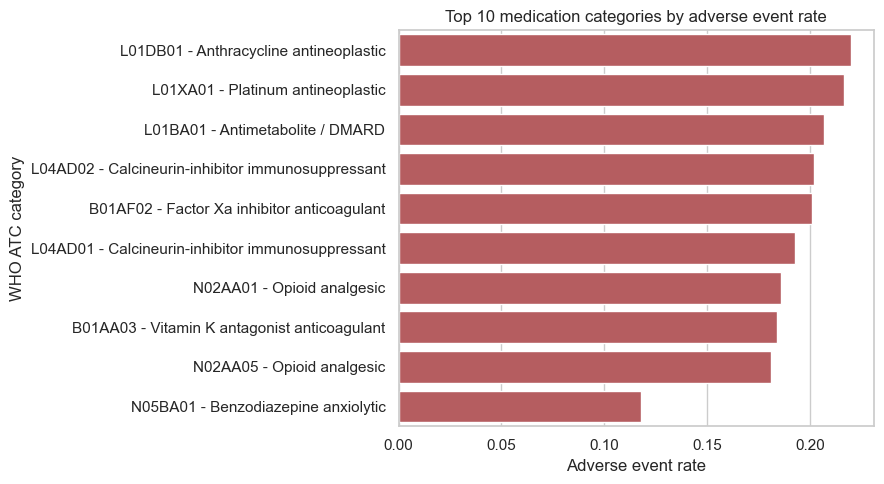

In [12]:
event_rate_by_category = (
    df.groupby("who_atc_category")["adverse_event_flag"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=event_rate_by_category.values, y=event_rate_by_category.index, color="#C44E52")
plt.xlabel("Adverse event rate")
plt.ylabel("WHO ATC category")
plt.title("Top 10 medication categories by adverse event rate")
plt.tight_layout()
plt.show()

### Task 6. Statistical inference

Before trusting a predictive model, confirm with formal statistical tests that the associations we're seeing are unlikely to be chance:
* A **chi-square test of independence** between medication category and adverse-event occurrence (two categorical variables).
* A **t-test** comparing patient age between the event and no-event groups (categorical vs. continuous).
* A **logistic regression** fit with `statsmodels` to get interpretable coefficients, p-values, and confidence intervals for the numeric risk factors.

In [13]:
contingency = pd.crosstab(df["who_atc_category"], df["adverse_event_flag"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.4g}")

Chi-square statistic: 1201.27
Degrees of freedom:   39
p-value:              1.327e-226


In [14]:
event_ages = df.loc[df["adverse_event_flag"] == 1, "age_at_start"]
no_event_ages = df.loc[df["adverse_event_flag"] == 0, "age_at_start"]

t_stat, p_value = stats.ttest_ind(event_ages, no_event_ages, equal_var=False)

print(f"Mean age (event):    {event_ages.mean():.1f}")
print(f"Mean age (no event): {no_event_ages.mean():.1f}")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.4g}")

Mean age (event):    55.1
Mean age (no event): 50.4
t-statistic: 12.70, p-value: 5.998e-36


In [15]:
inference_features = ["age_at_start", "bmi", "dose_ratio", "polypharmacy_count"]

X_inf = sm.add_constant(df[inference_features])
y_inf = df["adverse_event_flag"]

logit_model = sm.Logit(y_inf, X_inf).fit(disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:     adverse_event_flag   No. Observations:                31583
Model:                          Logit   Df Residuals:                    31578
Method:                           MLE   Df Model:                            4
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                 0.01171
Time:                        10:31:52   Log-Likelihood:                -8345.2
converged:                       True   LL-Null:                       -8444.0
Covariance Type:            nonrobust   LLR p-value:                 1.148e-41
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.8981      0.166    -23.491      0.000      -4.223      -3.573
age_at_start           0.0154      0.001     12.612      0.000       0.013       0.018
bmi                 

**Interpretation:** Age, dose, and polypharmacy count all come back statistically significant (p < 0.05) with positive coefficients — older patients, higher relative doses, and patients on more concurrent treatments all show higher adverse-event log-odds, which matches clinical intuition and matches how the underlying risk was generated. This gives us confidence that a predictive model built on these features is picking up a real signal, not noise.

## PACE: Construct

Consider these questions while working through this stage: which features are safe to use (no data leakage from post-event columns like `severity`?), how should you handle the class imbalance in `adverse_event_flag`, and how will you decide between the two models?

### Task 7. Prepare features and split the data

Use the numeric features engineered above plus the categorical medication/route/frequency/sex columns.

* **Do not** include `severity` or `required_hospitalization` as predictors — those are only known *after* an adverse event has already happened, so including them would leak the answer.
* **Do not** include the site or the prescriber either. The model must estimate risk from the patient and the treatment alone; otherwise it would *learn* a site's under-reporting as "low risk" and hide the very problem Task 11 needs to detect.
* **Split by patient, not by row.** Many patients have 2–4 treatments; a random row split would put the same patient in both train and test and inflate the test metrics. `GroupShuffleSplit` keeps each patient entirely on one side.

In [16]:
numeric_features = [
    "age_at_start", "bmi", "dose_ratio", "polypharmacy_count",
    "treatment_duration_days", "requires_prescription",
]
categorical_features = ["who_atc_category", "route", "frequency", "sex"]

X = df[numeric_features + categorical_features]
y = df["adverse_event_flag"]
groups = df["patient_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

shared = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate (train): {y_train.mean():.3f}, (test): {y_test.mean():.3f}")
print(f"Patients in both sets: {len(shared)}")

Train: (25234, 10), Test: (6349, 10)
Positive rate (train): 0.076, (test): 0.074
Patients in both sets: 0


### Task 8. Train Logistic Regression and Decision Tree models

Build a `ColumnTransformer` that scales the numeric features and one-hot encodes the categorical ones, then train both models through the same preprocessing pipeline so they're evaluated on an equal footing.

No `class_weight="balanced"`: re-weighting the classes inflates every predicted probability, and we need **calibrated** probabilities — summed over a site, they become the number of events we *expect* there (Task 11). The class imbalance is handled where it belongs: in the choice of the operational threshold.

In [17]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
log_reg.fit(X_train, y_train)

tree_clf = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, random_state=RANDOM_STATE)),
])
tree_clf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


### Task 9. Evaluate and compare the models

Adverse events are the minority class (~8% of treatments), so accuracy alone is misleading. Three questions matter:

1. **Ranking** — does the model put real events above non-events? (ROC-AUC)
2. **Calibration** — when it says 15%, do ~15% of those treatments have an event? (Brier score, calibration curve)
3. **Operational performance** — at the threshold the team will actually use, how many events are caught (recall) and how many flags are false alarms (precision)?

The default 0.5 cut-off makes no sense with an 8% base rate (it would flag almost nothing). The operational threshold is set by **capacity**: the monitoring team can proactively review roughly the top 10% of treatments, so each model flags scores above its own 90th percentile on the training set.

In [18]:
results = {}
for name, model in [("Logistic Regression", log_reg), ("Decision Tree", tree_clf)]:
    threshold = np.quantile(model.predict_proba(X_train)[:, 1], 0.90)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    results[name] = {
        "threshold": threshold, "probs": probs, "preds": preds,
        "roc_auc": roc_auc_score(y_test, probs), "brier": brier_score_loss(y_test, probs),
    }
    print(f"--- {name} (flag if score >= {threshold:.3f}) ---")
    print(classification_report(y_test, preds, target_names=["No event", "Event"], digits=3))
    print(f"ROC-AUC: {results[name]['roc_auc']:.3f}   Brier score: {results[name]['brier']:.4f}\n")

baseline_brier = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
print(f"Reference Brier score (always predicting the base rate): {baseline_brier:.4f}")

--- Logistic Regression (flag if score >= 0.157) ---
              precision    recall  f1-score   support

    No event      0.938     0.907     0.923      5881
       Event      0.178     0.252     0.209       468

    accuracy                          0.859      6349
   macro avg      0.558     0.580     0.566      6349
weighted avg      0.882     0.859     0.870      6349

ROC-AUC: 0.690   Brier score: 0.0661



--- Decision Tree (flag if score >= 0.090) ---
              precision    recall  f1-score   support

    No event      0.940     0.655     0.772      5881
       Event      0.099     0.474     0.163       468

    accuracy                          0.642      6349
   macro avg      0.519     0.565     0.468      6349
weighted avg      0.878     0.642     0.727      6349

ROC-AUC: 0.584   Brier score: 0.0675

Reference Brier score (always predicting the base rate): 0.0683


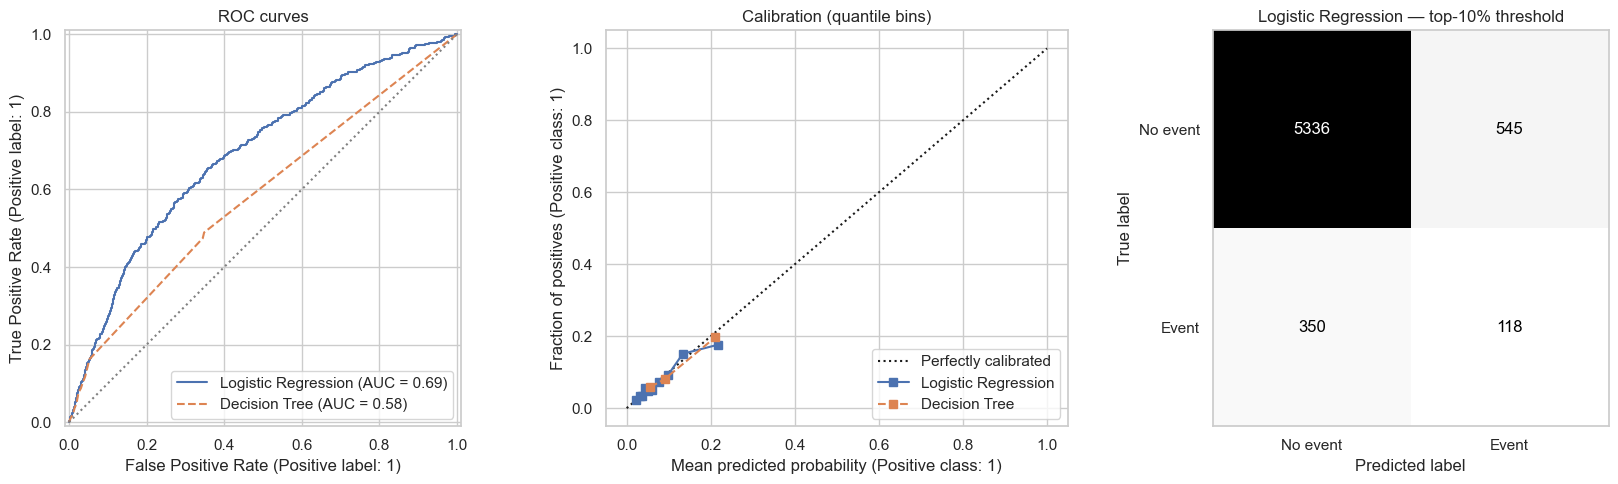

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for name, style in [("Logistic Regression", "-"), ("Decision Tree", "--")]:
    RocCurveDisplay.from_predictions(y_test, results[name]["probs"], ax=axes[0], name=name, linestyle=style)
    CalibrationDisplay.from_predictions(
        y_test, results[name]["probs"], n_bins=10, strategy="quantile", ax=axes[1], name=name, linestyle=style
    )
axes[0].plot([0, 1], [0, 1], linestyle=":", color="gray")
axes[0].set_title("ROC curves")
axes[1].set_title("Calibration (quantile bins)")

ConfusionMatrixDisplay.from_predictions(
    y_test, results["Logistic Regression"]["preds"], ax=axes[2],
    display_labels=["No event", "Event"], colorbar=False, cmap="Greys",
)
axes[2].set_title("Logistic Regression — top-10% threshold")
axes[2].grid(False)

plt.tight_layout()
plt.show()

**Model comparison:**

* **Logistic Regression** — ROC-AUC 0.690 and, more importantly, **well calibrated**: Brier score 0.0661 vs. 0.0683 for a model that always predicts the base rate, the calibration curve sits on the diagonal, and in Task 10 the observed event rate of each risk level matches its mean score almost exactly. At the top-10% threshold it catches 25% of test-set events with 17.8% precision — **2.4× the 7.4% base rate**.
* **Decision Tree** — ROC-AUC 0.584 and much coarser scores (a handful of leaves). Its value is explanatory: the top splits (below) can be shown to Helena and Marcus as if/then rules.

**Honest reading:** discrimination is modest. Every association in the Analyze stage was highly significant, yet the inferential model explains little variance (pseudo R² ≈ 0.01): with 31,583 rows, *significant* does not mean *predictive*. The model is not good enough to predict individual events — it is good enough to **rank** treatments for proactive review and, because it is calibrated, to tell us **how many events to expect** in any group. That second property is what powers the site-level monitoring in Execute.

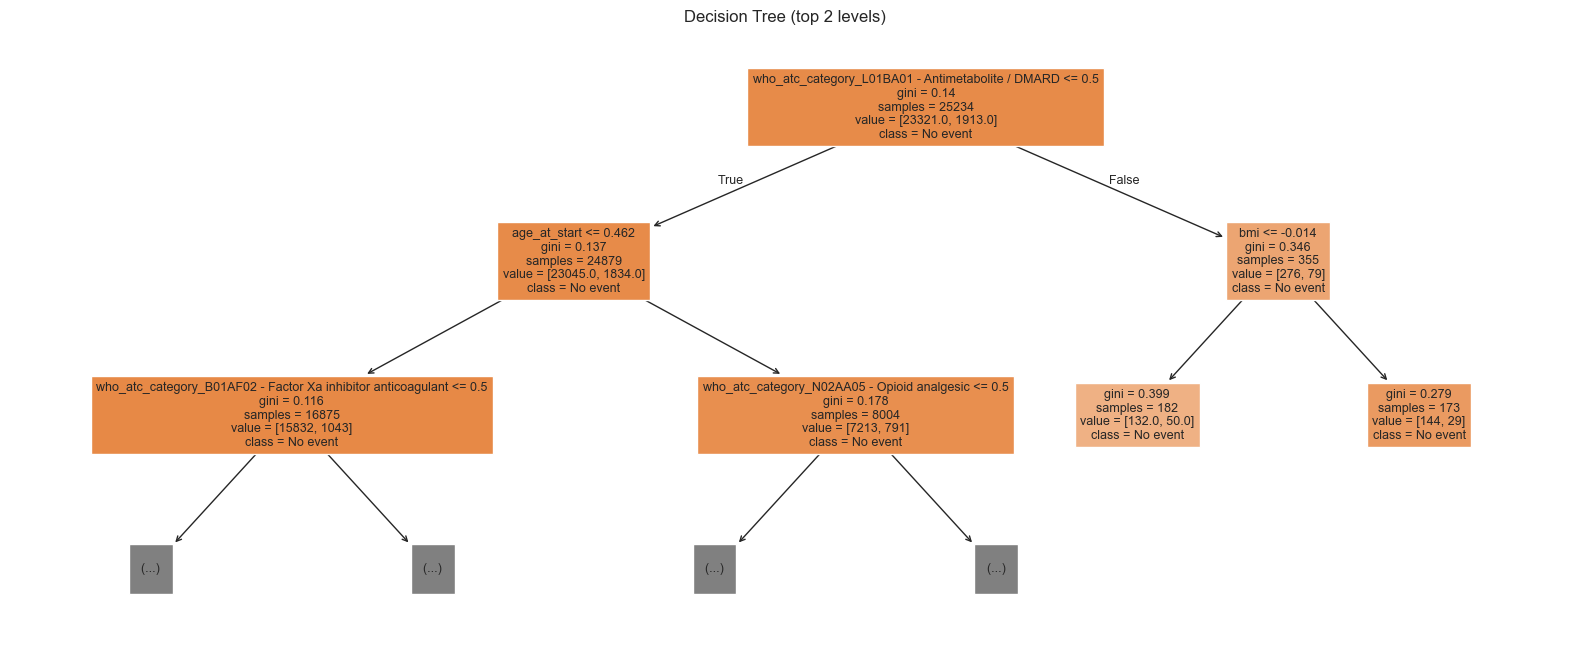

In [20]:
feature_names = (
    numeric_features
    + list(tree_clf.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)

plt.figure(figsize=(20, 8))
plot_tree(
    tree_clf.named_steps["model"],
    feature_names=feature_names,
    class_names=["No event", "Event"],
    filled=True,
    max_depth=2,
    fontsize=9,
)
plt.title("Decision Tree (top 2 levels)")
plt.show()

## PACE: Execute

Consider the PACE Strategy Document to reflect on this stage: how will you turn a probabilistic model into decisions a monitoring team can defend to an auditor, how will you present it to a non-technical audience, and what's the one chart Marta and Julian need to see first?

### Task 10. Pre-specified risk levels and the scored export

Risk-based quality management (ICH E6(R3), Good Clinical Practice, and ICH E8(R1), quality by design) does not prescribe numeric cut-offs. It asks that risk thresholds be:

* **pre-specified** — fixed before they are applied, not tuned after seeing the results;
* **documented and justified** — an auditor must be able to see why the line is where it is;
* **proportionate** — each level maps to a monitoring action whose intensity matches the risk;
* **periodically reviewed** — revisited as operational data accumulates.

*Scope note:* E6 and E8 govern clinical trials. Post-marketing pharmacovigilance is framed by ICH E2E (pharmacovigilance planning) and EMA GVP Module IX (signal management); the RBQM logic is borrowed here as a framework for proportionality.

**Why not fixed probability cut-offs such as 0.3 / 0.7?** With an 8% base rate, a calibrated model almost never scores above 0.3, so nearly every treatment would land in "Low" and the levels would carry no information. Instead, the cut-offs are tied to the team's **capacity**: High = top 10% of training-set scores (the operational threshold from Task 9), Medium = the next 20%. They are computed once, printed, and frozen.

**Out-of-fold scores.** Scoring each treatment with a model that was trained on it would give optimistic scores. Every exported `risk_score` comes from 5-fold cross-validation grouped by patient: each treatment is scored by a model that never saw that patient.

In [21]:
cv = GroupKFold(n_splits=5)
df["risk_score"] = cross_val_predict(log_reg, X, y, groups=groups, cv=cv, method="predict_proba")[:, 1]
df["predicted_risk_tree"] = cross_val_predict(tree_clf, X, y, groups=groups, cv=cv, method="predict_proba")[:, 1]

# Pre-specified cut-offs, fixed once on the training set and not re-derived on new data
train_scores = log_reg.predict_proba(X_train)[:, 1]
RISK_CUTOFFS = {
    "medium": float(np.quantile(train_scores, 0.70)),
    "high": float(results["Logistic Regression"]["threshold"]),  # top 10%
}
print("Pre-specified cut-offs:", {k: round(v, 4) for k, v in RISK_CUTOFFS.items()})

df["risk_level"] = pd.cut(
    df["risk_score"],
    bins=[0, RISK_CUTOFFS["medium"], RISK_CUTOFFS["high"], 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True,  # avoids NaN for a score of exactly 0.0
)
df["monitoring_action"] = df["risk_level"].map({
    "Low": "Routine surveillance",
    "Medium": "Enhanced case review",
    "High": "Proactive patient outreach",
}).astype(str)

df.groupby("risk_level", observed=True).agg(
    treatments=("treatment_id", "size"),
    mean_risk_score=("risk_score", "mean"),
    observed_event_rate=("adverse_event_flag", "mean"),
)

Pre-specified cut-offs: {'medium': 0.085, 'high': 0.1571}


,treatments,mean_risk_score,observed_event_rate
risk_level,,,
Low,22300,0.045692,0.045919
Medium,6148,0.113755,0.113696
High,3135,0.211371,0.209888


In [22]:
export_df = df.drop(columns=["birth_date"])  # age_at_start is enough downstream
export_df["risk_level"] = export_df["risk_level"].astype(str)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
export_path = PROCESSED_DIR / "tableau_pharma_risk_data.csv"
export_df.to_csv(export_path, index=False)
print(f"Exported {len(export_df):,} rows to: {export_path}")

Exported 31,583 rows to: processed\tableau_pharma_risk_data.csv


In [23]:
try:
    import pantab

    hyper_path = PROCESSED_DIR / "tableau_pharma_risk_data.hyper"
    pantab.frame_to_hyper(export_df, hyper_path, table="predictions")
    print(f"Wrote native Tableau extract to {hyper_path}")
except ImportError:
    print("pantab not installed -- run `pip install pantab` to also export a")
    print("native .hyper extract. The CSV export above works with Tableau either way.")

Wrote native Tableau extract to processed\tableau_pharma_risk_data.hyper


### Task 11. KPIs, KRIs and Quality Tolerance Limits

The model scores individual treatments; risk-based monitoring works with **aggregates**. The bridge between the two is calibration: summing the calibrated `risk_score` over a group gives the number of adverse events we **expect** there given its patients and treatments. Comparing observed with expected (**O/E**) separates "this site treats riskier patients" from "this site behaves differently".

| Indicator | Question it answers | Level |
|---|---|---|
| **KPI** (Key Performance Indicator) | Is the pharmacovigilance process performing? (timeliness, coverage) | Programme |
| **KRI** (Key Risk Indicator) | Is a site drifting in a way that threatens data quality or patient safety? | Site |
| **QTL** (Quality Tolerance Limit) | Has the programme as a whole crossed a limit that requires investigation? | Programme |

Each limit has two lines, both pre-specified:

* **Secondary limit** (early warning, 95% Poisson control limit) → review and watch.
* **QTL / action limit** (99.8% control limit) → documented investigation and corrective action.

In [24]:
reported = df[df["adverse_event_flag"] == 1]
active = df[df["status"] == "Active"]

kpis = pd.Series({
    "Patients": df["patient_id"].nunique(),
    "Prescribers": df["doctor_id"].nunique(),
    "Sites": df["hospital"].nunique(),
    "Medications": df["medication_id"].nunique(),
    "Treatments": df["treatment_id"].nunique(),
    "Adverse events reported": int(df["adverse_event_flag"].sum()),
    "Adverse event rate (%)": round(100 * df["adverse_event_flag"].mean(), 2),
    "Hospitalisations": int(df["required_hospitalization"].sum()),
    "Reports within 15 days (%)": round(100 * (reported["report_lag_days"] <= 15).mean(), 1),
    "Active treatments": len(active),
    "Active treatments flagged High": int((active["risk_level"] == "High").sum()),
})
kpis.to_frame("value")

,value
Patients,17060.00
Prescribers,200.00
Sites,10.00
Medications,40.00
Treatments,31583.00
Adverse events reported,2381.00
Adverse event rate (%),7.54
Hospitalisations,470.00
Reports within 15 days (%),91.70
Active treatments,6899.00


In [25]:
def poisson_oe_limits(expected, coverage):
    """Two-sided Poisson control limits for an observed/expected ratio."""
    alpha = 1 - coverage
    lower = stats.poisson.ppf(alpha / 2, expected) / expected
    upper = stats.poisson.ppf(1 - alpha / 2, expected) / expected
    return lower, upper


site_kri = df.groupby("hospital").agg(
    treatments=("treatment_id", "size"),
    observed_events=("adverse_event_flag", "sum"),
    expected_events=("risk_score", "sum"),
)
site_kri["oe_ratio"] = site_kri["observed_events"] / site_kri["expected_events"]
for label, coverage in [("secondary", 0.95), ("qtl", 0.998)]:
    site_kri[f"{label}_lower"], site_kri[f"{label}_upper"] = poisson_oe_limits(site_kri["expected_events"], coverage)

print(f"Programme-wide O/E: {df['adverse_event_flag'].sum() / df['risk_score'].sum():.3f}")
site_kri.sort_values("oe_ratio").round(3)

Programme-wide O/E: 1.000


,treatments,observed_events,expected_events,oe_ratio,secondary_lower,secondary_upper,qtl_lower,qtl_upper
hospital,,,,,,,,
Northgate University Hospital,2610,133,195.360,0.681,0.860,1.141,0.788,1.229
Summit Health System,2562,136,192.620,0.706,0.862,1.142,0.784,1.230
Meridian General Hospital,2905,224,221.567,1.011,0.871,1.133,0.799,1.214
Harborview Clinical Center,3041,231,225.856,1.023,0.872,1.133,0.801,1.213
Pinecrest Community Hospital,3508,274,267.525,1.024,0.882,1.121,0.815,1.192
Ashford Medical Center,3009,236,228.666,1.032,0.875,1.133,0.800,1.211
St. Alden Medical Center,3950,317,300.665,1.054,0.888,1.114,0.828,1.184
Crestwood Memorial Hospital,2896,232,217.335,1.067,0.870,1.136,0.796,1.215
Riverside Health Institute,3089,256,230.445,1.111,0.872,1.133,0.803,1.211


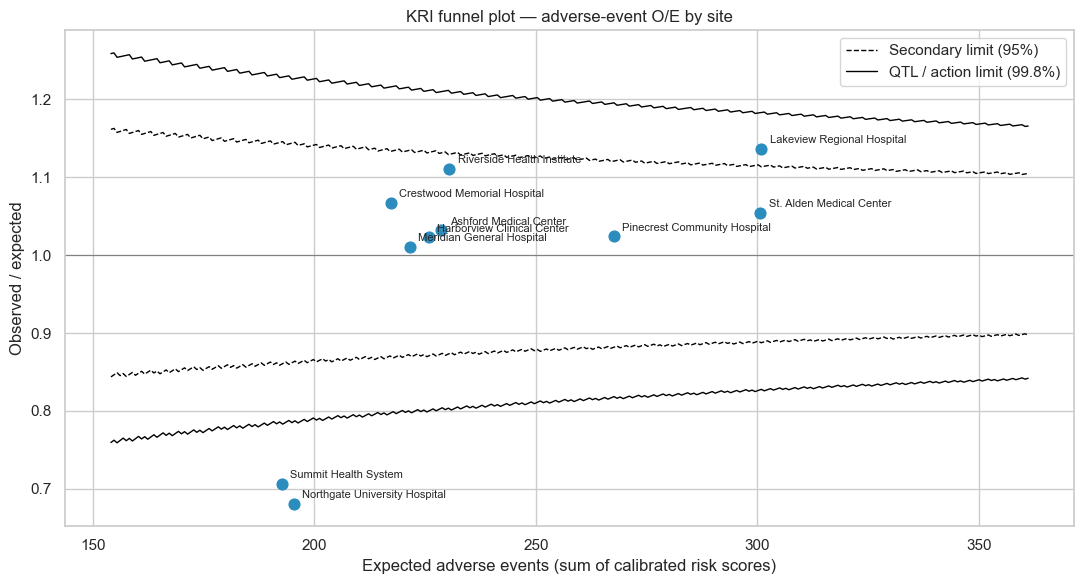

In [26]:
exp_grid = np.linspace(site_kri["expected_events"].min() * 0.8, site_kri["expected_events"].max() * 1.2, 300)

fig, ax = plt.subplots(figsize=(11, 6))
for coverage, style, label in [(0.95, "--", "Secondary limit (95%)"), (0.998, "-", "QTL / action limit (99.8%)")]:
    lower, upper = poisson_oe_limits(exp_grid, coverage)
    ax.plot(exp_grid, lower, color="black", linestyle=style, linewidth=1, label=label)
    ax.plot(exp_grid, upper, color="black", linestyle=style, linewidth=1)
ax.axhline(1, color="gray", linewidth=0.8)
ax.scatter(site_kri["expected_events"], site_kri["oe_ratio"], s=60, color="#2b8cbe", zorder=3)
for site, row in site_kri.iterrows():
    ax.annotate(site, (row["expected_events"], row["oe_ratio"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Expected adverse events (sum of calibrated risk scores)")
ax.set_ylabel("Observed / expected")
ax.set_title("KRI funnel plot — adverse-event O/E by site")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Programme-level QTL.** The QTL is tracked quarterly (by treatment start). Fixed horizontal limits are easier to communicate and audit than limits that move every quarter, so they are pre-specified once from the **median quarterly expected volume**: the secondary limit and the QTL are the 95% and 99.8% Poisson bands at that volume. Quarters with fewer than 20 expected events are too small to judge and are not plotted.

Median quarterly expected events: 92
Pre-specified limits (lower, upper): {'secondary': (0.8, 1.21), 'qtl': (0.7, 1.34)}


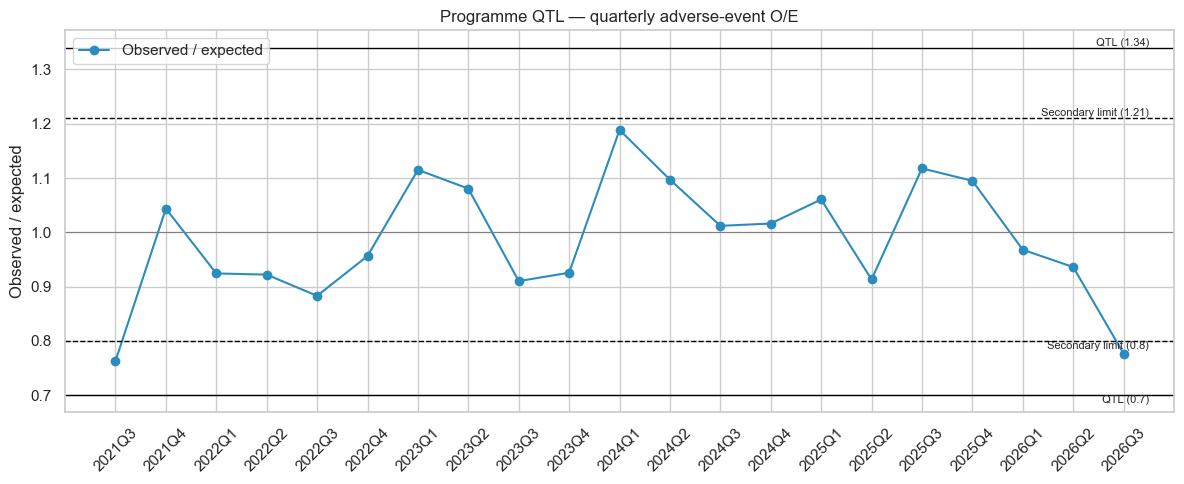

,observed_events,expected_events,oe_ratio,secondary_lower,secondary_upper,qtl_lower,qtl_upper
start_date,,,,,,,
2021Q3,20,26.212,0.763,0.8,1.21,0.7,1.34
2026Q3,91,117.223,0.776,0.8,1.21,0.7,1.34


In [27]:
quarterly = df.groupby(df["start_date"].dt.to_period("Q")).agg(
    observed_events=("adverse_event_flag", "sum"),
    expected_events=("risk_score", "sum"),
)
quarterly = quarterly[quarterly["expected_events"] >= 20]
quarterly["oe_ratio"] = quarterly["observed_events"] / quarterly["expected_events"]

median_expected = quarterly["expected_events"].median()
QTL_LIMITS = {}
for label, coverage in [("secondary", 0.95), ("qtl", 0.998)]:
    lower, upper = poisson_oe_limits(median_expected, coverage)
    QTL_LIMITS[label] = (round(float(lower), 2), round(float(upper), 2))
    quarterly[f"{label}_lower"], quarterly[f"{label}_upper"] = QTL_LIMITS[label]
print(f"Median quarterly expected events: {median_expected:.0f}")
print("Pre-specified limits (lower, upper):", QTL_LIMITS)

fig, ax = plt.subplots(figsize=(12, 5))
x = quarterly.index.astype(str)
ax.plot(x, quarterly["oe_ratio"], marker="o", color="#2b8cbe", label="Observed / expected")
for label, style, text in [("secondary", "--", "Secondary limit"), ("qtl", "-", "QTL")]:
    lower, upper = QTL_LIMITS[label]
    ax.axhline(lower, color="black", linestyle=style, linewidth=1)
    ax.axhline(upper, color="black", linestyle=style, linewidth=1)
    ax.text(len(x) - 0.5, upper, f" {text} ({upper})", va="bottom", ha="right", fontsize=8)
    ax.text(len(x) - 0.5, lower, f" {text} ({lower})", va="top", ha="right", fontsize=8)
ax.axhline(1, color="gray", linewidth=0.8)
ax.set_ylabel("Observed / expected")
ax.set_title("Programme QTL — quarterly adverse-event O/E")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

quarterly[(quarterly["oe_ratio"] < QTL_LIMITS["secondary"][0]) | (quarterly["oe_ratio"] > QTL_LIMITS["secondary"][1])].round(3)

In [28]:
site_kri.reset_index().to_csv(PROCESSED_DIR / "tableau_kri_by_hospital.csv", index=False)
quarterly.assign(quarter=quarterly.index.astype(str)).to_csv(PROCESSED_DIR / "tableau_qtl_quarterly.csv", index=False)
print("Wrote tableau_kri_by_hospital.csv and tableau_qtl_quarterly.csv")

Wrote tableau_kri_by_hospital.csv and tableau_qtl_quarterly.csv


### Task 12. Site Risk Score

Adverse-event O/E is only one way a site can go wrong. Five KRIs are tracked per site, each with a pre-specified secondary limit and action limit:

| KRI | What it detects | Secondary limit | Action limit |
|---|---|---|---|
| Late reports > 15 days (%) | Delayed data capture | 5% | 10% |
| Mean reporting lag (days) | Delayed data capture | 7 days | 15 days |
| Adverse-event O/E | Under- or over-reporting | \|z\| ≥ 2 | \|z\| ≥ 3 |
| Female patients (%) | Unusual patient mix | \|z\| ≥ 2 | \|z\| ≥ 3 |
| Severe / fatal events (%) | Unusual severity profile | \|z\| ≥ 2 | \|z\| ≥ 3 |

* The two lag KRIs use **operational** limits anchored to the 15-day reporting clock: with ~250 reports per site, a statistical test would flag even a one-day difference, which no one needs to act on.
* The proportion KRIs compare each site with the **median site**, not with the pooled network. If one site concentrates most of the female patients, the pooled rest of the network becomes male-skewed and *every* other site would look abnormal; the median is robust to that spill-over.
* Points per KRI: 0 = within limits, 1 = secondary limit breached, 2 = action limit breached. **Site Risk Score = points / maximum × 100.**
* Levels and proportionate actions: **Low** (< 20) routine central monitoring; **Medium** (20–49) targeted remote review; **High** (≥ 50) for-cause audit.

In [29]:
def median_site_z(successes, n):
    """z-score of each site's proportion vs. the median site (robust network reference)."""
    p_site = successes / n
    p_ref = p_site.median()
    return (p_site - p_ref) / np.sqrt(p_ref * (1 - p_ref) / n)


def points_from_z(z):
    return np.select([z.abs() >= 3, z.abs() >= 2], [2, 1], 0)


def points_from_value(value, secondary, action):
    return np.select([value >= action, value >= secondary], [2, 1], 0)


site_patients = df.drop_duplicates(["hospital", "patient_id"]).groupby("hospital").agg(
    patients=("patient_id", "size"),
    female=("sex", lambda s: (s == "F").sum()),
)
site_events = reported.groupby("hospital").agg(
    severe=("severity", lambda s: s.isin(["Severe", "Fatal"]).sum()),
    late_reports=("report_lag_days", lambda s: (s > 15).sum()),
    mean_report_lag=("report_lag_days", "mean"),
)
site = site_kri[["observed_events", "expected_events"]].join(site_patients).join(site_events)

pct_late = 100 * site["late_reports"] / site["observed_events"]
oe_z = (site["observed_events"] - site["expected_events"]) / np.sqrt(site["expected_events"])
sex_z = median_site_z(site["female"], site["patients"])
severe_z = median_site_z(site["severe"], site["observed_events"])

kri_long = pd.concat([
    pd.DataFrame({"kri": "Late reports > 15 days (%)", "value": pct_late, "z_score": np.nan,
                  "points": points_from_value(pct_late, 5, 10), "limit_basis": "value",
                  "secondary_limit": 5, "action_limit": 10}),
    pd.DataFrame({"kri": "Mean reporting lag (days)", "value": site["mean_report_lag"], "z_score": np.nan,
                  "points": points_from_value(site["mean_report_lag"], 7, 15), "limit_basis": "value",
                  "secondary_limit": 7, "action_limit": 15}),
    pd.DataFrame({"kri": "Adverse-event O/E", "value": site["observed_events"] / site["expected_events"],
                  "z_score": oe_z, "points": points_from_z(oe_z), "limit_basis": "|z|",
                  "secondary_limit": 2, "action_limit": 3}),
    pd.DataFrame({"kri": "Female patients (%)", "value": 100 * site["female"] / site["patients"],
                  "z_score": sex_z, "points": points_from_z(sex_z), "limit_basis": "|z|",
                  "secondary_limit": 2, "action_limit": 3}),
    pd.DataFrame({"kri": "Severe / fatal events (%)", "value": 100 * site["severe"] / site["observed_events"],
                  "z_score": severe_z, "points": points_from_z(severe_z), "limit_basis": "|z|",
                  "secondary_limit": 2, "action_limit": 3}),
]).rename_axis("hospital").reset_index()
kri_long["status"] = kri_long["points"].map({0: "Within limits", 1: "Secondary limit breached", 2: "Action limit breached"})

site_score = kri_long.groupby("hospital")["points"].sum().to_frame()
site_score["site_risk_score"] = 100 * site_score["points"] / (2 * kri_long["kri"].nunique())
site_score["site_risk_level"] = pd.cut(
    site_score["site_risk_score"], bins=[0, 20, 50, 100.01], labels=["Low", "Medium", "High"], right=False
).astype(str)
site_score["site_action"] = site_score["site_risk_level"].map({
    "Low": "Routine central monitoring",
    "Medium": "Targeted remote review",
    "High": "For-cause audit",
})
site_score["triggered_by"] = (
    kri_long[kri_long["points"] > 0].groupby("hospital")["kri"].agg(", ".join)
    .reindex(site_score.index).fillna("-")
)
site_score.sort_values("site_risk_score", ascending=False)

,points,site_risk_score,site_risk_level,site_action,triggered_by
hospital,,,,,
Northgate University Hospital,6,60.0,High,For-cause audit,"Late reports > 15 days (%), Mean reporting lag..."
Summit Health System,6,60.0,High,For-cause audit,"Late reports > 15 days (%), Mean reporting lag..."
Harborview Clinical Center,2,20.0,Medium,Targeted remote review,Female patients (%)
Lakeview Regional Hospital,1,10.0,Low,Routine central monitoring,Adverse-event O/E
Ashford Medical Center,0,0.0,Low,Routine central monitoring,-
Crestwood Memorial Hospital,0,0.0,Low,Routine central monitoring,-
Meridian General Hospital,0,0.0,Low,Routine central monitoring,-
Pinecrest Community Hospital,0,0.0,Low,Routine central monitoring,-
Riverside Health Institute,0,0.0,Low,Routine central monitoring,-


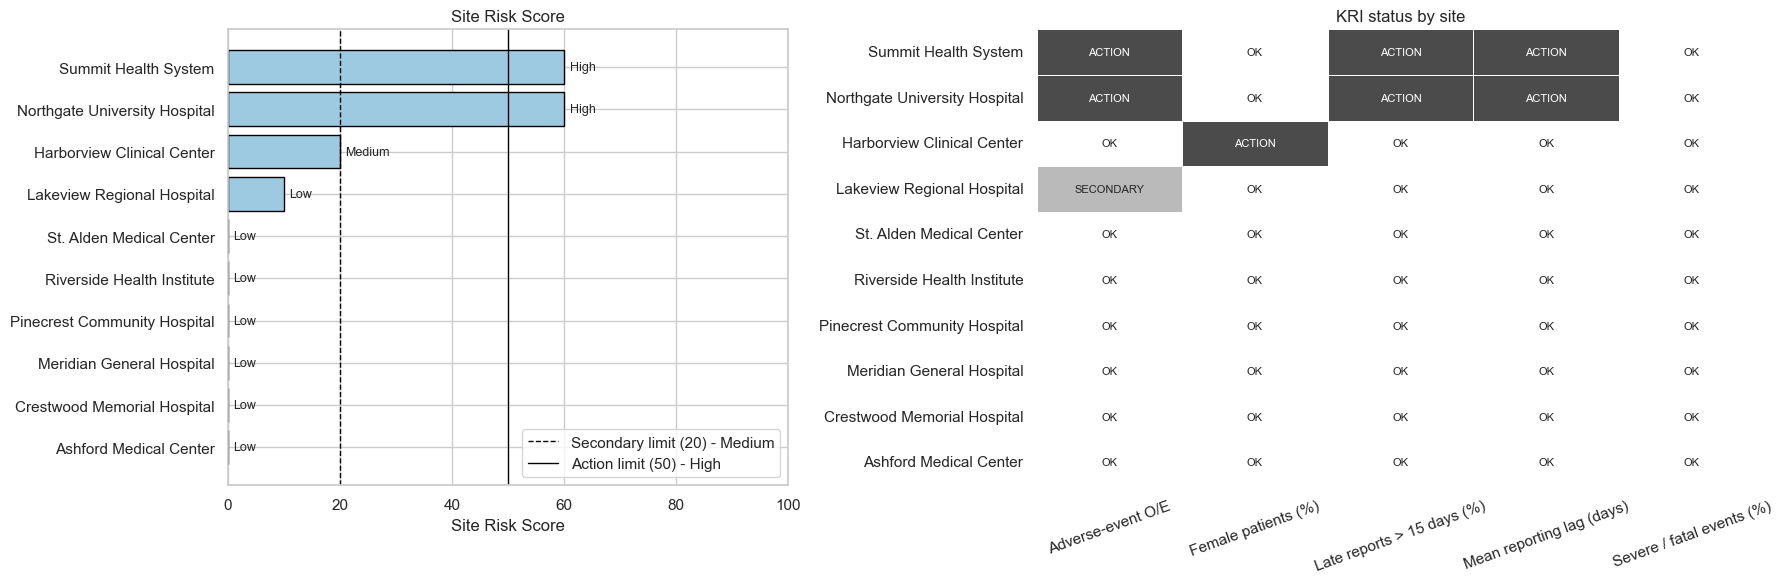

In [30]:
ranked = site_score.sort_values("site_risk_score")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 1.3]})

ax = axes[0]
bars = ax.barh(ranked.index, ranked["site_risk_score"], color="#9ecae1", edgecolor="black")
for bar, level in zip(bars, ranked["site_risk_level"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, level, va="center", fontsize=9)
ax.axvline(20, color="black", linestyle="--", linewidth=1, label="Secondary limit (20) - Medium")
ax.axvline(50, color="black", linestyle="-", linewidth=1, label="Action limit (50) - High")
ax.set_xlim(0, 100)
ax.set_xlabel("Site Risk Score")
ax.set_title("Site Risk Score")
ax.legend(loc="lower right")

points = kri_long.pivot(index="hospital", columns="kri", values="points").loc[ranked.index[::-1]]
labels = points.replace({0: "OK", 1: "SECONDARY", 2: "ACTION"})
sns.heatmap(points, annot=labels, fmt="", cmap="Greys", vmin=0, vmax=2.6, cbar=False,
            linewidths=0.5, linecolor="white", ax=axes[1], annot_kws={"fontsize": 8})
axes[1].set_title("KRI status by site")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [31]:
site_risk_export = kri_long.merge(site_score.drop(columns="points"), left_on="hospital", right_index=True)
site_risk_export.to_csv(PROCESSED_DIR / "tableau_site_risk.csv", index=False)
print(f"Wrote {len(site_risk_export)} rows to tableau_site_risk.csv")

Wrote 50 rows to tableau_site_risk.csv


**Reading the result:**

* **Summit Health System and Northgate University Hospital — High (60).** About three-quarters of their reports arrive after the 15-day clock (mean lag ≈ 41–42 days vs. 1.5–2.8 days elsewhere), and they report only 68–71% of the adverse events their patient mix predicts (O/E z ≈ −4). Their patients are not safer — their events are **not in the database yet**. This is the backlog that record-level cleaning could never see (Task 3b). Action: for-cause audit of the data-entry process.
* **Harborview Clinical Center — Medium (20).** 89.5% of its patients are women vs. ~46% at the median site. Every other KRI is within limits and its O/E is 1.02, so the data are being captured correctly; the question is *why* the population differs (referral pattern? specialty mix?) and whether conclusions drawn there generalise. Action: targeted remote review.
* **Lakeview Regional Hospital — Low (10).** O/E 1.14 crosses the secondary limit only. With ten sites and five KRIs, an occasional early-warning breach is expected from random fluctuation alone; this is exactly why the secondary limit triggers *watching*, not action.
* **Programme QTL.** The most recent quarter (2026Q3) dropped to O/E 0.78 — below the secondary limit (0.80) but above the QTL (0.70). The early warning fired before the action limit was reached, and the site view explains why: the two slow sites have not yet entered their recent events.

### Task 13. Plan the Tableau dashboard

Connect Tableau to `processed/tableau_pharma_risk_data.csv` (or the `.hyper` extract), plus the three aggregate files `tableau_kri_by_hospital.csv`, `tableau_qtl_quarterly.csv` and `tableau_site_risk.csv`, and design a dashboard for Helena's team. Sketch out:

1. **KPIs** — what 2-3 numbers should be visible at a glance?

**Exemplar response:** Overall adverse-event rate across active treatments; count of currently active treatments with `risk_level` = High; average predicted risk by medication category (to spot a category trending upward).

2. **Calculated fields** — what derived fields will you need beyond what's in the export (e.g., a risk-tier bucket)?

**Exemplar response:** `risk_score`, `risk_level` and `monitoring_action` are already exported, but Tableau should also compute: `Days Since Treatment Start` (freshness of the risk score), a `High Risk Flag` boolean for quick filtering, and a `Model Agreement` field comparing `risk_score` vs. `predicted_risk_tree` to flag treatments where the two models disagree (worth a second look).

3. **Filters** — what should a Pharmacovigilance analyst be able to slice by?

**Exemplar response:** Medication / WHO ATC category, treatment status (Active only, by default), risk tier, doctor specialty, and a date range on treatment start.

4. **Accessibility** — given Helena's visual impairment, how will you avoid relying on color alone?

**Exemplar response:** Use a colorblind-safe palette, but back every risk-tier color with a text label ("High"/"Medium"/"Low") directly on the mark or in a legend with high-contrast text, avoid red/green-only encodings, and keep font sizes and contrast ratios large enough for low-vision use. Provide the underlying numbers in a tooltip and a sortable table view as an alternative to any purely visual chart.

5. **Site monitoring** — how will the RBQM layer appear?

**Exemplar response:** A *Site Monitoring* view with the Site Risk Score ranking, the KRI status grid, the O/E funnel and the quarterly QTL chart, with the secondary and action limits drawn as labelled reference lines (dashed and solid, so they don't depend on color).

### Task 14. Executive summary

Write a short executive summary for Marta Fields and Julian Cross covering:

1. **Summary of tasks completed**

**Exemplar response:** Extracted and joined the five pharmacovigilance source tables via SQL, cleaned the resulting dataset (~31.5k treatments across 20k patients), engineered age/BMI/polypharmacy/dose features, ran descriptive and inferential statistics to confirm real associations with adverse events, and trained/compared a Logistic Regression and a Decision Tree classifier to score adverse-event risk per treatment (patient-grouped validation, calibrated probabilities, out-of-fold scores). Defined pre-specified Low/Medium/High risk levels tied to monitoring actions, built site-level KRIs, a programme QTL and a Site Risk Score with secondary and action limits, and exported Tableau-ready files.

2. **Results of the data/variable assessment**

**Exemplar response:** Adverse events occur in roughly 8% of treatments. The logistic model ranks treatments modestly (ROC-AUC 0.69) but is well calibrated (programme O/E = 1.00), so its scores can be summed into expected event counts. Age, dose relative to the medication's typical dose, medication category, and polypharmacy count all show statistically significant associations with adverse-event occurrence (chi-square and t-test p-values well below 0.05; age, dose ratio and polypharmacy significant in the logistic regression; BMI is not). `severity` and `required_hospitalization` were excluded as model inputs since they're only known after an event occurs and would leak the target.

3. **Recommended next steps**

**Exemplar response:** Validate the model against Pharmacovigilance's own case-review outcomes once real (non-synthetic) labels are available; consider adding drug-drug interaction pairs as a feature given the polypharmacy signal; build and user-test the Tableau dashboard directly with Helena's team before wider rollout; revisit the risk-tier thresholds once the monitoring team has operational capacity data (how many "High" cases they can realistically review per week).

4. **Site monitoring findings**

**Exemplar response:** Two sites (Summit Health System, Northgate University Hospital) breach the action limits for reporting delay and under-reporting (O/E ≈ 0.7) and are recommended for a for-cause audit; their backlog also pushes the latest programme quarter below the QTL secondary limit. Harborview Clinical Center has a markedly female patient population (89.5%) with otherwise normal data capture and warrants a targeted review. The remaining seven sites are within limits.

## Appendix — required libraries

| Category | Library | Why |
|---|---|---|
| SQL connectivity | `SQLAlchemy` | Connects Python to the (local SQLite / any relational) database and runs the extraction query |
| Data manipulation | `pandas` | DataFrames, cleaning, joins, grouping |
| Numerical computation | `numpy` | Vectorized math, `NaN` handling |
| Statistics | `scipy`, `statsmodels` | Hypothesis tests, inferential logistic regression |
| Machine learning | `scikit-learn` | Preprocessing, LogisticRegression, DecisionTreeClassifier, evaluation metrics |
| Visualization | `matplotlib`, `seaborn` | Distributions, boxplots, ROC curves |
| Tableau integration | `pantab` | Writes a native `.hyper` extract directly from a pandas DataFrame (optional; the CSV export works without it) |
| Tableau integration | `tableauserverclient` | Automates publishing the extract to Tableau Server/Cloud (optional, not exercised in this notebook) |